In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
df=pd.read_csv('/content/ecom_db.csv')

In [57]:
df.head(5)

,User_ID,Product_ID,Category,Price,Discount,Final_Price,Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [58]:
#Feature encoding
#x variable gives everything in dataset without Purchase_Date
#Y variable gives only Purchase_Date
x=df.iloc[:,:-1].values
# Convert 'Purchase_Date' to datetime objects and then to ordinal numbers
y = pd.to_datetime(df.iloc[:,-1], format='%d-%m-%Y').apply(lambda x: x.toordinal()).values

In [59]:
#One Hot encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[0, 1, 2, 6])],remainder='passthrough')
x=ct.fit_transform(x).toarray()


In [60]:
x

array([[  0.  ,   0.  ,   0.  , ...,  36.53,  15.  ,  31.05],
       [  0.  ,   0.  ,   0.  , ..., 232.79,  20.  , 186.23],
       [  0.  ,   0.  ,   0.  , ..., 317.02,  25.  , 237.76],
       ...,
       [  0.  ,   0.  ,   0.  , ..., 389.76,   0.  , 389.76],
       [  0.  ,   0.  ,   0.  , ..., 447.66,  30.  , 313.36],
       [  0.  ,   0.  ,   0.  , ..., 235.77,  30.  , 165.04]])

In [61]:
#Train & test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [62]:
#Train & test split and Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure x_train and x_test are correctly split from x before scaling
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [63]:
#Models
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [64]:
y_pred=regressor.predict(x_test)

In [65]:
y_pred

array([739051.69782154, 739050.49574461, 739050.12101949, 739052.32888147,
       739048.02060159, 739054.37943007, 739049.45195758, 739050.23166551,
       739052.37310113, 739051.16983575, 739049.98604664, 739049.58270864,
       739050.1443346 , 739047.86548069, 739045.34404954, 739049.3314005 ,
       739049.40380614, 739049.96529113, 739045.35095092, 739050.26414019,
       739054.43626222, 739051.10884156, 739048.28424935, 739049.85073215,
       739049.88634297, 739052.75158879, 739048.42386246, 739048.60135757,
       739049.96752381, 739048.87727679, 739051.24876608, 739047.34525686,
       739050.83847527, 739049.49094845, 739048.05571917, 739052.3573279 ,
       739048.43166105, 739049.41117744, 739049.56611559, 739049.54474389,
       739050.87889853, 739050.66383309, 739046.80327561, 739048.44999287,
       739052.0444171 , 739046.86568183, 739052.37641228, 739053.30068654,
       739051.09859704, 739050.51874593, 739049.67547771, 739049.17652965,
       739052.61881817, 7

In [66]:
y_test

array([738964, 739115, 739206, 739200, 739091, 739086, 739076, 739049,
       739040, 739095, 738934, 739190, 738917, 738976, 739202, 739004,
       738912, 739052, 739195, 739205, 739080, 738899, 738962, 739083,
       738935, 739050, 739096, 739105, 739086, 739117, 738886, 738937,
       739113, 738953, 739015, 738909, 738948, 739082, 738925, 738922,
       739041, 738912, 739209, 739125, 739078, 739016, 739151, 739152,
       739058, 739020, 739038, 739141, 739155, 738969, 738900, 739046,
       739197, 739107, 739018, 739206, 739028, 739128, 739136, 738989,
       738925, 738949, 738962, 739193, 739094, 738887, 739139, 739156,
       739106, 739164, 739133, 739202, 738994, 739016, 739178, 739052,
       738991, 738987, 739060, 739112, 738887, 738927, 739185, 738951,
       738902, 739036, 739030, 739142, 739055, 738975, 739192, 738998,
       738925, 739081, 738958, 738913, 739053, 738929, 738911, 739031,
       739145, 738902, 739145, 739104, 738905, 738949, 738921, 739176,
      

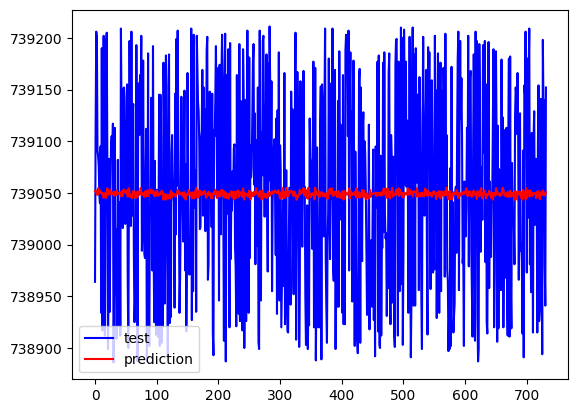

In [67]:
#Plot test vs prediction
plt.plot(y_test,color='blue',label='test')
plt.plot(y_pred,color='red',label='prediction')
plt.legend()
plt.show()

In [68]:
df.head(1)

,User_ID,Product_ID,Category,Price,Discount,Final_Price,Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024


In [97]:
data=[['337c166f', 'f414122f-e', 'Sports', 36.53, 15, 31.05, 'Net Banking']]

In [98]:
#create pandas dataframe
new_df=pd.DataFrame(data)

In [100]:
new_df = pd.DataFrame(data, columns=df.iloc[:,:-1].columns)
new_data_encoded = ct.transform(new_df).toarray()
new_data_scaled = sc.transform(new_data_encoded)
prediction = regressor.predict(new_data_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(


In [101]:
print(sc.n_features_in_)
print(x_train.shape)

7335
(2928, 7335)


In [102]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)

In [104]:
#Predictions
single=regressor.predict(new_data_scaled)

In [105]:
print(single)

[739049.61096475]


In [109]:
#Keep R & D and try to predict profit..>Simple Linear Regression
df=pd.read_csv('/content/50_Startups_dataset.csv')

In [111]:
x=df[['R&D Spend','Administration']]
y=df[['Profit']]

In [113]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=42)

In [114]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [115]:
y_pred=model.predict(x_test)

In [116]:
y_pred

array([[122796.10259945],
       [146061.70365144],
       [ 70576.88783243],
       [145951.77662212],
       [154376.81206748],
       [154972.74985289],
       [ 68106.48720778],
       [ 58110.10879315],
       [ 62121.28685405],
       [135423.0179582 ],
       [137833.19990965],
       [110781.73223172],
       [104569.98235311],
       [ 98683.67750964],
       [107264.6742444 ],
       [172932.779845  ],
       [ 81766.98968248],
       [108399.80290028],
       [ 91117.21901954],
       [141328.51759075],
       [110332.12134779],
       [118484.45612173],
       [ 79180.00309246],
       [174705.38670917],
       [119056.02429579],
       [156064.40329683],
       [ 70472.42680511],
       [ 80294.3942957 ],
       [ 99829.99086576],
       [ 77118.53116638],
       [124002.02375799],
       [108393.07212514],
       [118106.12441736],
       [ 57522.58239741],
       [107679.14282653],
       [151672.88626811],
       [ 68128.57649926],
       [147503.48034328],
       [1180

In [117]:
y_test

,Profit
12,141585.62
4,166188.04
37,89949.24
8,152211.87
3,182902.09
6,156122.61
41,77798.93
46,49490.85
47,42559.83
15,129917.14


In [118]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 257619235.98517948
R-squared: 0.8503482243590689


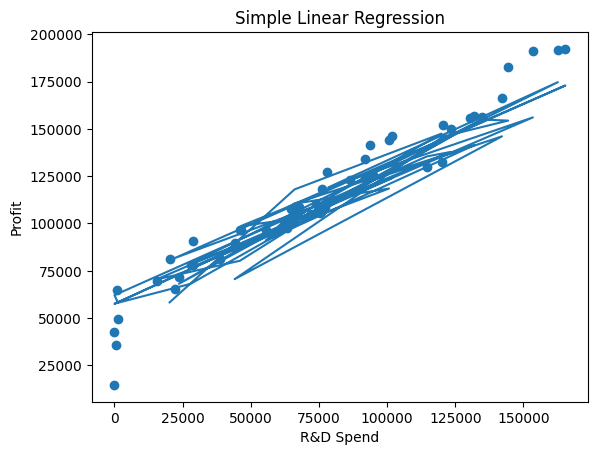

In [120]:
plt.scatter(x['R&D Spend'],y)
plt.plot(x_test['R&D Spend'],y_pred)
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.title('Simple Linear Regression')
plt.show()

In [121]:
#Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=4)
x_poly=poly.fit_transform(x)


In [126]:
#Create Polynomial features
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [127]:
model=LinearRegression()
model.fit(x_train_poly,y_train)

LinearRegression()

In [128]:
y_pred=model.predict(x_test_poly)

In [129]:
y_pred

array([[138944.98308938],
       [344353.55402058],
       [143207.95908224],
       [160369.52771926],
       [266024.67632088],
       [185225.76113571],
       [ 62890.80837019],
       [ 52561.6052996 ],
       [ 86788.56035288],
       [183675.20962263],
       [233616.24377787],
       [119002.956477  ],
       [140311.55360931],
       [114245.8920108 ],
       [108713.28787175],
       [274765.44761529],
       [117538.7164329 ],
       [108283.03841842],
       [ 96559.28367883],
       [282503.5063178 ],
       [110298.23880003],
       [212051.40774718],
       [ 73857.00421971],
       [233835.49967498],
       [116356.14633255],
       [349418.46866971],
       [ 70805.51396241],
       [ 94764.74930664],
       [114519.15955483],
       [ 66898.11844491],
       [176623.77833469],
       [112612.37416941],
       [149838.67276976],
       [ 53985.50350847],
       [122149.1233167 ],
       [179833.15526292],
       [ 54309.32507255],
       [153348.90773225],
       [1495

In [130]:
print("R2 Score:",r2_score(y_test,y_pred))

R2 Score: -0.7469104491545562


In [131]:
#Multi Linear Regression
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [132]:
y_pred=model.predict(x_test)

In [133]:
y_pred

array([[122796.10259945],
       [146061.70365144],
       [ 70576.88783243],
       [145951.77662212],
       [154376.81206748],
       [154972.74985289],
       [ 68106.48720778],
       [ 58110.10879315],
       [ 62121.28685405],
       [135423.0179582 ],
       [137833.19990965],
       [110781.73223172],
       [104569.98235311],
       [ 98683.67750964],
       [107264.6742444 ],
       [172932.779845  ],
       [ 81766.98968248],
       [108399.80290028],
       [ 91117.21901954],
       [141328.51759075],
       [110332.12134779],
       [118484.45612173],
       [ 79180.00309246],
       [174705.38670917],
       [119056.02429579],
       [156064.40329683],
       [ 70472.42680511],
       [ 80294.3942957 ],
       [ 99829.99086576],
       [ 77118.53116638],
       [124002.02375799],
       [108393.07212514],
       [118106.12441736],
       [ 57522.58239741],
       [107679.14282653],
       [151672.88626811],
       [ 68128.57649926],
       [147503.48034328],
       [1180

In [135]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score)
print("R2 Score:",r2_score(y_test,y_pred))

Accuracy Score: <function accuracy_score at 0x797ae1cd9b20>
R2 Score: 0.8503482243590689


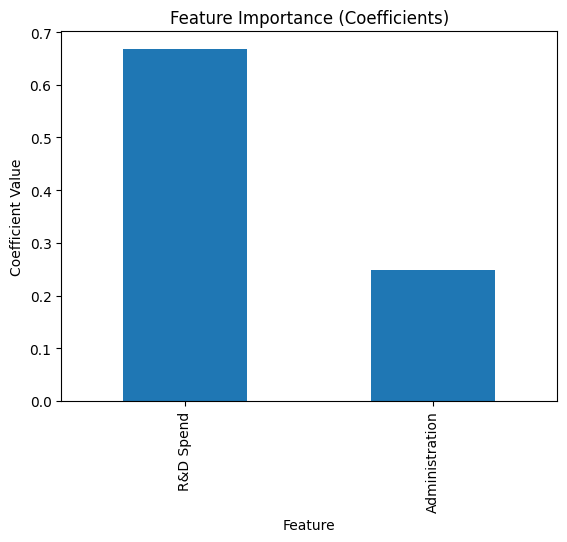

In [140]:
coef = pd.DataFrame({
    'Feature': x.columns, # Use the column names from the original x for the multi-linear model
    'Coefficient': model.coef_.flatten()
})

coef.plot(x='Feature', y='Coefficient', kind='bar', legend=False)
plt.ylabel("Coefficient Value")
plt.title("Feature Importance (Coefficients)")
plt.show()